# 🏁 Final Conclusion

The Exploratory Data Analysis (EDA) successfully identified the major factors influencing NYC taxi trip durations and provided valuable insights into passenger travel behavior, temporal trends, and geographic demand patterns.

## Key Conclusions

1. **Trip duration exhibited a heavily right-skewed distribution**, indicating that most trips are short, while a small number of trips have significantly longer durations.

2. **Trip distance was identified as the strongest predictor of trip duration**, showing a clear positive relationship with travel time.

3. **The relationship between trip distance and trip duration is non-linear**, suggesting that additional factors such as traffic congestion and route conditions affect travel times.

4. **Passenger count showed minimal influence on trip duration**, indicating that the number of passengers is not a primary driver of trip completion time.

5. **Temporal analysis revealed clear rush-hour patterns**, with longer trip durations observed during morning and evening peak traffic periods.

6. **Geographic analysis demonstrated strong spatial concentration of taxi demand**, with certain pickup and drop-off locations contributing to a substantial proportion of total trips.

7. **Correlation analysis confirmed that trip distance has the strongest association with trip duration**, while other features exhibited relatively weak linear relationships.

8. **Several outliers were identified within trip duration and trip distance distributions**. These extreme observations likely represent valid real-world scenarios such as airport trips, heavy traffic conditions, and long-distance travel.

9. **Outliers were retained rather than aggressively removed**, as they contain important business information and reflect genuine operational variability.

10. **Logarithmic transformation (`log1p`) was determined to be the preferred approach for handling skewness**, reducing the influence of extreme values while preserving the integrity of the dataset.

11. **The presence of non-linear relationships and outliers suggests that tree-based machine learning algorithms** (e.g., Random Forest and XGBoost) are more suitable than traditional linear models for this problem.

12. **The dataset demonstrates strong temporal, spatial, and behavioral patterns**, making feature engineering a critical step for improving predictive performance.

13. **Overall data quality and exploratory findings indicate that the dataset is well-prepared for machine learning applications** after appropriate preprocessing and feature engineering.

## Final Summary

The EDA revealed that NYC taxi trip duration is influenced by a combination of **trip distance, traffic-related temporal patterns, and geographic characteristics**. The analysis highlighted the importance of preserving meaningful outliers, addressing skewed distributions through transformation techniques, and leveraging robust machine learning models capable of capturing complex non-linear relationships.

These insights establish a strong foundation for the next stages of the project, including **feature engineering, model development, evaluation, and deployment**.


---
---

# Exploratory Data Analysis (EDA)

## Executive Summary

This notebook performs an in-depth exploratory data analysis on the feature-engineered NYC Yellow Taxi dataset to understand the factors influencing trip duration and fare estimation.

The primary objective is to identify temporal, spatial, and trip-related patterns that can support the development of machine learning models capable of predicting:

- Trip Duration Before Ride Initiation
- Expected Fare Before Ride Initiation

The analysis focuses on uncovering relationships between input features and target variables while validating data quality and generating actionable business insights.

# Business Understanding

Passengers often seek accurate estimates of trip duration and fare before confirming a ride request. Reliable predictions improve customer satisfaction, pricing transparency, and operational planning.

The objective of this project is to build predictive models that estimate trip duration and fare using only information reasonably available before the trip begins.

## Business Objectives

- Improve fare transparency for passengers.
- Provide realistic travel time expectations.
- Support efficient fleet management and driver allocation.
- Identify factors contributing to longer trips and higher fares.
- Enable data-driven decision-making in taxi operations.

# Import Required Libraries

The following libraries are used for data manipulation, visualization, and statistical analysis.

In [11]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

plt.style.use("default")
sns.set_palette("deep")

# Load Feature Engineered Dataset

Load the processed dataset generated from the feature engineering stage.

In [12]:
df = pd.read_parquet(
    "/home/ed/Desktop/NYC_Taxi_Demand_Forecasting/USECASE2_Trip_Fare_Forecasting/data/feature_engineered_taxi_data.parquet"
)

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (3499962, 12)


,tpep_pickup_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,trip_duration,pickup_hour,pickup_dayofweek,pickup_day,is_weekend,is_rush_hour,Location_Pair
0,2026-01-01 00:54:04,1.0,0.97,239,238,5.550000,0,3,1,0,0,239_238
1,2026-01-01 00:15:22,4.0,5.58,142,209,42.800000,0,3,1,0,0,142_209
2,2026-01-01 00:47:11,2.0,2.33,144,137,13.600000,0,3,1,0,0,144_137
3,2026-01-01 00:17:54,1.0,1.30,142,50,10.633333,0,3,1,0,0,142_50
4,2026-01-01 00:34:14,1.0,5.34,161,45,37.733333,0,3,1,0,0,161_45


# Dataset Overview

Examine the overall structure of the dataset, including dimensions, data types, and sample records.

In [13]:

print(f"Number of Rows: {df.shape[0]:,}")
print(f"Number of Columns: {df.shape[1]}")


Number of Rows: 3,499,962
Number of Columns: 12


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3499962 entries, 0 to 3499961
Data columns (total 12 columns):
 #   Column                Dtype         
---  ------                -----         
 0   tpep_pickup_datetime  datetime64[us]
 1   passenger_count       float64       
 2   trip_distance         float64       
 3   PULocationID          int32         
 4   DOLocationID          int32         
 5   trip_duration         float64       
 6   pickup_hour           int32         
 7   pickup_dayofweek      int32         
 8   pickup_day            int32         
 9   is_weekend            int64         
 10  is_rush_hour          int64         
 11  Location_Pair         object        
dtypes: datetime64[us](1), float64(3), int32(5), int64(2), object(1)
memory usage: 253.7+ MB


In [15]:
df.sample(10)

,tpep_pickup_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,trip_duration,pickup_hour,pickup_dayofweek,pickup_day,is_weekend,is_rush_hour,Location_Pair
1016559,2026-01-13 19:41:27,1.0,0.97,236,141,6.766667,19,1,13,0,1,236_141
881406,2026-01-12 10:47:43,1.0,0.56,237,162,2.950000,10,0,12,0,1,237_162
2494910,2026-01-31 21:01:50,2.0,1.70,162,236,11.983333,21,5,31,1,0,162_236
2339544,2026-01-30 08:05:37,1.0,1.40,162,107,17.800000,8,4,30,0,1,162_107
1319441,2026-01-16 21:20:12,1.0,1.90,164,237,12.783333,21,4,16,0,0,164_237
1471295,2026-01-18 20:38:50,1.0,0.61,48,161,4.400000,20,6,18,1,0,48_161
974111,2026-01-13 12:21:50,1.0,1.22,186,163,16.800000,12,1,13,0,0,186_163
284409,2026-01-05 08:23:56,1.0,0.77,262,236,7.283333,8,0,5,0,1,262_236
1605348,2026-01-20 16:08:32,1.0,7.17,138,100,41.916667,16,1,20,0,1,138_100
1115411,2026-01-14 19:02:05,3.0,0.84,231,158,4.250000,19,2,14,0,1,231_158


# Data Dictionary

The following table describes the variables available in the dataset.

In [17]:
data_dictionary = pd.DataFrame({

    "Feature": [

        "tpep_pickup_datetime",
        "passenger_count",
        "trip_distance",
        "PULocationID",
        "DOLocationID",
        "trip_duration",
        "pickup_hour",
        "pickup_dayofweek",
        "pickup_day",
        "is_weekend",
        "is_rush_hour",
        "Location_Pair"

    ],

    "Description": [

        "Original pickup timestamp",
        "Number of passengers",
        "Estimated trip distance in miles",
        "Pickup location zone identifier",
        "Dropoff location zone identifier",
        "Trip duration in minutes (Target Variable)",
        "Hour of pickup",
        "Day of week of pickup",
        "Day of month of pickup",
        "Weekend indicator",
        "Rush hour indicator",
        "Combined pickup-dropoff route identifier"

    ],

    "Type": [

        "Datetime",
        "Numerical",
        "Numerical",
        "Categorical",
        "Categorical",
        "Target",
        "Numerical",
        "Numerical",
        "Numerical",
        "Binary",
        "Binary",
        "Categorical"

    ]

})

data_dictionary

,Feature,Description,Type
0,tpep_pickup_datetime,Original pickup timestamp,Datetime
1,passenger_count,Number of passengers,Numerical
2,trip_distance,Estimated trip distance in miles,Numerical
3,PULocationID,Pickup location zone identifier,Categorical
4,DOLocationID,Dropoff location zone identifier,Categorical
5,trip_duration,Trip duration in minutes (Target Variable),Target
6,pickup_hour,Hour of pickup,Numerical
7,pickup_dayofweek,Day of week of pickup,Numerical
8,pickup_day,Day of month of pickup,Numerical
9,is_weekend,Weekend indicator,Binary


# Data Quality Assessment

Evaluate the dataset for potential quality issues, including:

- Missing values
- Duplicate records
- Overall dataset completeness

Data quality validation ensures the reliability of subsequent analyses and model development.

In [18]:
missing_values = pd.DataFrame({

    "Missing Count": df.isnull().sum(),

    "Missing Percentage": (
        df.isnull().mean() * 100
    ).round(2)

})

missing_values[
    missing_values["Missing Count"] > 0
].sort_values(
    "Missing Count",
    ascending=False
)

,Missing Count,Missing Percentage


### Observation

The dataset is expected to contain no missing values following the cleaning procedures implemented in Notebook 2.

In [19]:
duplicates = df.duplicated().sum()

print(
    f"Duplicate Records: {duplicates:,}"
)

Duplicate Records: 0


### Observation

Duplicate observations were previously removed during the data cleaning phase. The final dataset should not contain duplicate records.

# Data Type Validation

Validate that each feature has been assigned an appropriate data type to support accurate analysis and efficient model training.

In [20]:
dtype_df = pd.DataFrame({

    "Column": df.columns,

    "Data Type": df.dtypes.values

})

dtype_df

,Column,Data Type
0,tpep_pickup_datetime,datetime64[us]
1,passenger_count,float64
2,trip_distance,float64
3,PULocationID,int32
4,DOLocationID,int32
5,trip_duration,float64
6,pickup_hour,int32
7,pickup_dayofweek,int32
8,pickup_day,int32
9,is_weekend,int64


In [22]:
numerical_features = df.select_dtypes(
    include=["int64", "float64", "int32"]
).columns.tolist()

print("Numerical Features:")
numerical_features

Numerical Features:


['passenger_count',
 'trip_distance',
 'PULocationID',
 'DOLocationID',
 'trip_duration',
 'pickup_hour',
 'pickup_dayofweek',
 'pickup_day',
 'is_weekend',
 'is_rush_hour']

In [23]:
categorical_features = [

    "PULocationID",

    "DOLocationID",

    "Location_Pair"

]

print("Categorial Features:")
categorical_features

Categorial Features:


['PULocationID', 'DOLocationID', 'Location_Pair']

In [24]:
binary_features = [

    "is_weekend",

    "is_rush_hour"

]

print("Binary Feature:")
binary_features

Binary Feature:


['is_weekend', 'is_rush_hour']

In [26]:
datetime_features = [

    "tpep_pickup_datetime"

]

print("Datetime Features:")
datetime_features

Datetime Features:


['tpep_pickup_datetime']

# Descriptive Statistics

Generate summary statistics for numerical variables to understand their central tendency, variability, and distribution characteristics.

In [27]:
df[
    numerical_features
].describe().T

,count,mean,std,min,25%,50%,75%,max
passenger_count,3499962.0,1.186869,0.573038,1.000000,1.000000,1.000000,1.000000,6.000000
trip_distance,3499962.0,3.482794,4.195791,0.010000,1.090000,1.900000,3.890000,95.100000
PULocationID,3499962.0,161.495252,67.022332,1.000000,114.000000,161.000000,233.000000,265.000000
DOLocationID,3499962.0,161.054830,71.022493,1.000000,107.000000,162.000000,234.000000,265.000000
trip_duration,3499962.0,17.111908,13.753058,0.016667,8.333333,13.533333,21.333333,179.966667
pickup_hour,3499962.0,14.037682,6.036386,0.000000,10.000000,15.000000,19.000000,23.000000
pickup_dayofweek,3499962.0,3.157328,1.835313,0.000000,2.000000,3.000000,5.000000,6.000000
pickup_day,3499962.0,16.429719,8.858874,1.000000,9.000000,16.000000,24.000000,31.000000
is_weekend,3499962.0,0.287659,0.452671,0.000000,0.000000,0.000000,1.000000,1.000000
is_rush_hour,3499962.0,0.404899,0.490873,0.000000,0.000000,0.000000,1.000000,1.000000


# Datetime Feature Validation

Validate the pickup timestamp range to understand the temporal coverage of the dataset.

In [28]:
print(
    "Start Date:",
    df["tpep_pickup_datetime"].min()
)

print(
    "End Date:",
    df["tpep_pickup_datetime"].max()
)

Start Date: 2025-12-31 23:57:29
End Date: 2026-02-01 00:45:01


# 7. Univariate Analysis

We analyze each feature independently to understand its distribution, central tendency, and variability.

This helps identify:
- Skewed distributions
- Rare categories
- Initial data patterns

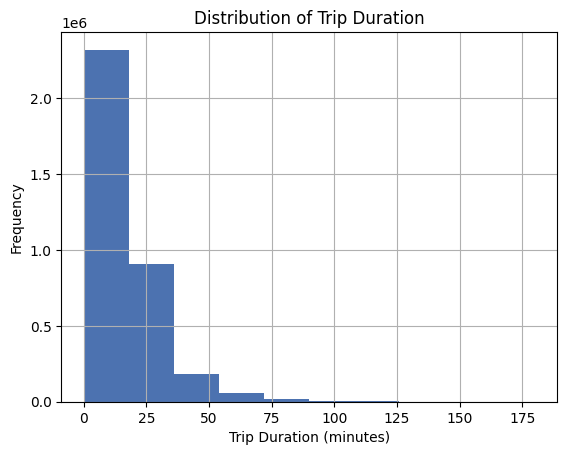

In [29]:
import matplotlib.pyplot as plt

df["trip_duration"].hist()
plt.title("Distribution of Trip Duration")
plt.xlabel("Trip Duration (minutes)")
plt.ylabel("Frequency")
plt.show()

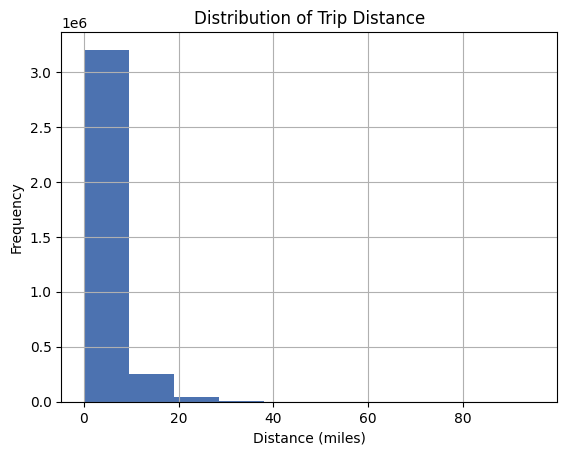

In [30]:
df["trip_distance"].hist()
plt.title("Distribution of Trip Distance")
plt.xlabel("Distance (miles)")
plt.ylabel("Frequency")
plt.show()

# 📊 7. Univariate Analysis — Observations

## 🚕 Trip Duration Distribution

### 📌 Observation
- The distribution of **trip_duration** is heavily right-skewed (positively skewed).
- Most trips are concentrated in the range of **0 to ~30 minutes**.
- A small number of trips extend beyond **50–175 minutes**, forming a long tail.

### 📊  Interpretation
- This is a typical real-world taxi distribution pattern:
  - Short trips dominate (within city travel)
  - Long trips represent airport rides, intercity travel, or congestion delays
- The presence of a long tail indicates:
  - Strong outlier influence
  - Non-linear relationships in the dataset

### ⚠️ Modeling Impact
- Linear models may be heavily affected by skewness and outliers.
- Error metrics like MAE and RMSE may increase due to extreme values.

### 💡 Recommendation
- Apply one of the following:
  - Log transformation (`log1p`)
  - Percentile-based capping (e.g., 99th percentile)
  - Robust regression models

---

## 📏 Trip Distance Distribution

### 📌 Observation
- **trip_distance** is also highly right-skewed.
- Majority of trips fall between **0–10 miles**.
- A small number of trips extend beyond **20–90 miles**, forming a long tail.

### 📊  Interpretation
- This reflects urban mobility behavior:
  - Dense city rides dominate the dataset
  - Long-distance trips are rare but important
- Strong relationship expected between:
  - trip_distance ↔ trip_duration

### ⚠️ Modeling Impact
- High skewness may:
  - Bias mean-based statistics
  - Increase variance in predictions
- Can impact linear model stability

### 💡 Recommendation
- Apply:
  - Log transformation for normalization
  - Standard scaling for linear models
  - Outlier handling for extreme values (>50 miles)

---


In [52]:
df["trip_duration"] = np.log1p(df["trip_duration"])
df["trip_distance"] = np.log1p(df["trip_distance"])

# 8. Outlier Analysis

Outliers can heavily impact regression models like Linear Regression and Tree-based models.

We focus on:
- Trip duration
- Trip distance
- Passenger count

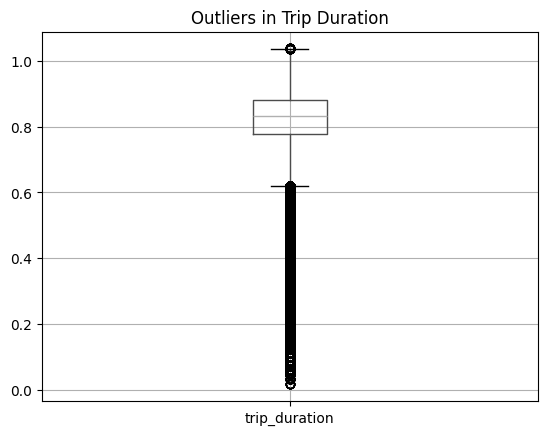

In [53]:
df[["trip_duration"]].boxplot()
plt.title("Outliers in Trip Duration")
plt.show()

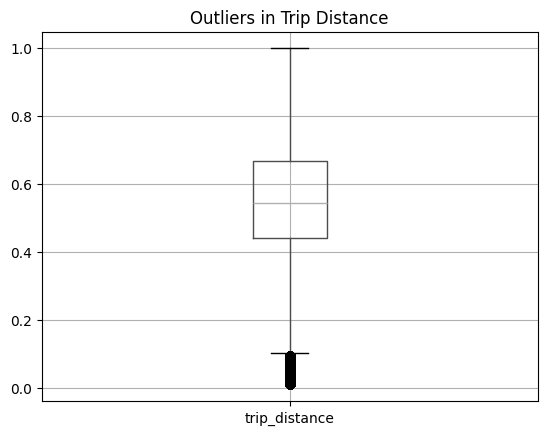

In [54]:
df[["trip_distance"]].boxplot()
plt.title("Outliers in Trip Distance")
plt.show()

# 🚨 8. Outlier Analysis — Trip Duration (Boxplot)

### 📌 Observation
- The boxplot shows a tight interquartile range (IQR).
- Numerous points exist beyond the upper whisker, indicating outliers.
- Extreme values reach up to **~175 minutes**.

### 📊 Interpretation
These outliers likely represent:
- 🚖 Airport trips (JFK, LaGuardia)
- 🚦 Traffic congestion events
- ❌ Data errors (GPS/timestamp inconsistencies)

### ⚠️ Modeling Impact
- Outliers inflate mean and variance.
- They negatively affect:
  - Regression accuracy
  - Loss functions (especially RMSE)
- Can bias model toward extreme values.

 🛠️ Handling Strategy

### 1. Log Transformation (Recommended)
- Applied `log1p` transformation to reduce skewness.
- Compresses extreme values while preserving data integrity.
- Improves model stability and learning performance.

### 2. Optional Capping (For baseline models only)
- Extreme values can be capped using percentile-based thresholds (e.g., 99th percentile).
- Helps reduce the influence of extreme outliers in simpler models.

### 3. Robust Modeling Approach
- Tree-based models such as Random Forest and XGBoost are preferred.
- These models are inherently less sensitive to outliers.

---

## 🎯 Final Decision
Instead of removing outliers, they are **transformed and retained**, as they represent meaningful real-world behavior. The combination of log transformation and robust machine learning models ensures both accuracy and realism.

---

## 🏆 Conclusion
Outliers were not treated as noise to be removed, but as important signals of real-world variability. By applying log transformation and using robust models, the dataset is made suitable for accurate and stable predictive modeling without losing critical business information.

Extremely high trip durations or distances may represent:
- Airport trips
- Traffic congestion
- Data errors (GPS glitches)

These must be handled carefully depending on model objective.

In [45]:
df["trip_duration"] = np.log1p(df["trip_duration"])
df["trip_distance"] = np.log1p(df["trip_distance"])

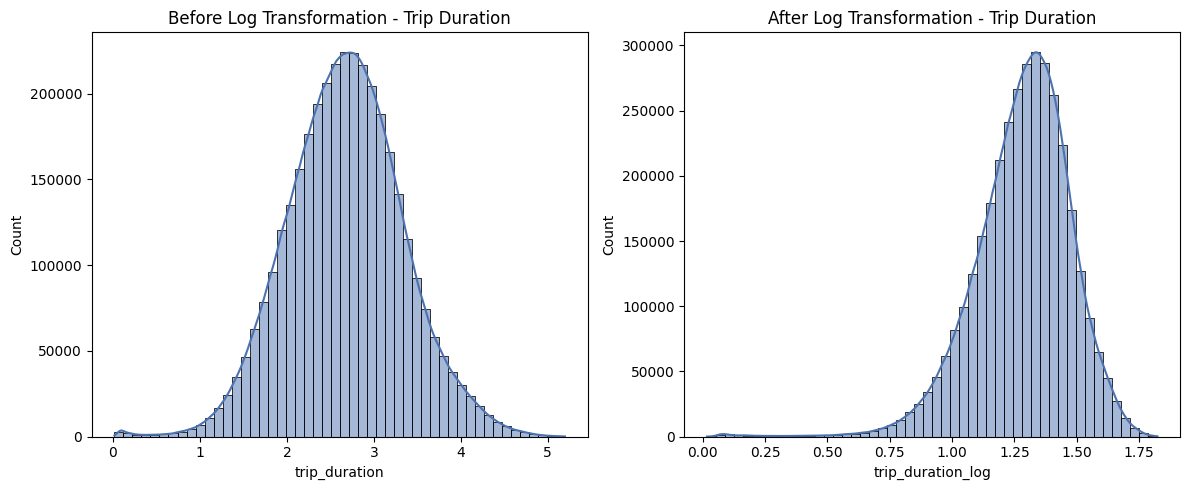

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Create log transformed column
df["trip_duration_log"] = np.log1p(df["trip_duration"])

# Plot
plt.figure(figsize=(12,5))

# Original
plt.subplot(1,2,1)
sns.histplot(df["trip_duration"], bins=50, kde=True)
plt.title("Before Log Transformation - Trip Duration")

# After log
plt.subplot(1,2,2)
sns.histplot(df["trip_duration_log"], bins=50, kde=True)
plt.title("After Log Transformation - Trip Duration")

plt.tight_layout()
plt.show()

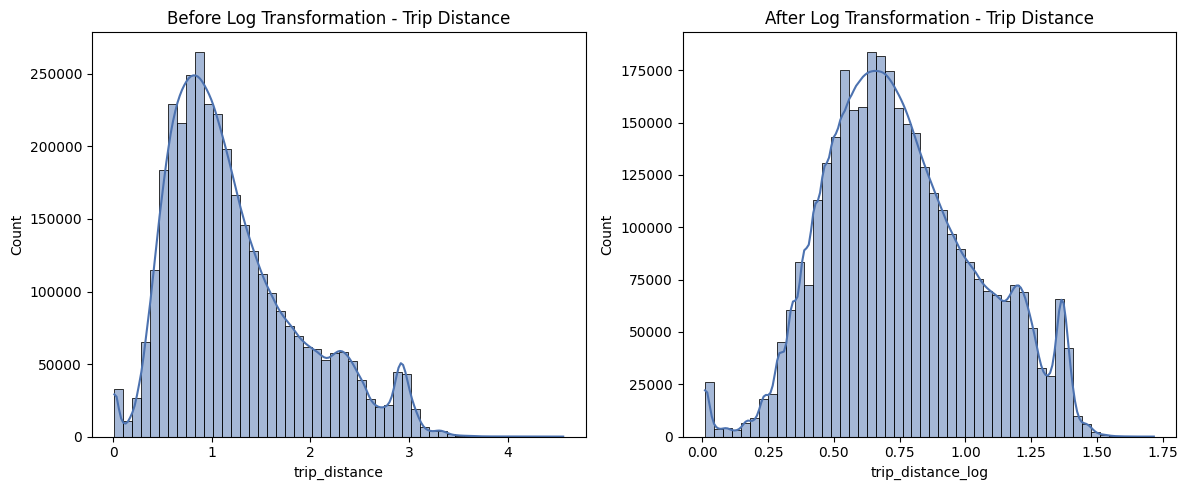

In [47]:
df["trip_distance_log"] = np.log1p(df["trip_distance"])

plt.figure(figsize=(12,5))

# Original
plt.subplot(1,2,1)
sns.histplot(df["trip_distance"], bins=50, kde=True)
plt.title("Before Log Transformation - Trip Distance")

# After log
plt.subplot(1,2,2)
sns.histplot(df["trip_distance_log"], bins=50, kde=True)
plt.title("After Log Transformation - Trip Distance")

plt.tight_layout()
plt.show()

# 9. Bivariate Analysis

We analyze relationships between features and target variable (`trip_duration`).

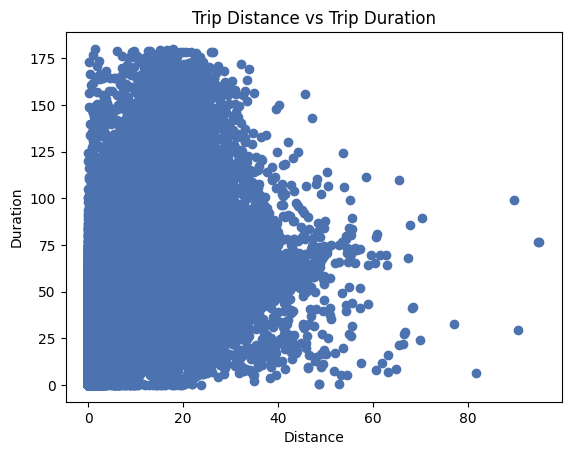

In [33]:
plt.scatter(df["trip_distance"], df["trip_duration"])
plt.title("Trip Distance vs Trip Duration")
plt.xlabel("Distance")
plt.ylabel("Duration")
plt.show()

## 🚕 1. Trip Distance vs Trip Duration (Scatter Plot)

### 📌 Observation
- A **weak to moderate positive correlation** exists between trip distance and trip duration.
- Most trips are concentrated in the **0–20 miles distance** and **0–50 minutes duration** range.
- The relationship is not strictly linear.
- Several outliers are present:
  - Short distance but high duration
  - Long distance but relatively moderate duration

### 🧠  Interpretation
- Trip duration is influenced not only by distance but also by:
  - 🚦 Traffic congestion
  - 🛣️ Route inefficiencies
  - ✈️ Airport / highway travel patterns
- This indicates a **non-linear real-world system**.

### ⚠️ Modeling Insight
- Linear models may underperform due to non-linearity.
- Tree-based models (XGBoost, Random Forest) are more suitable.

---

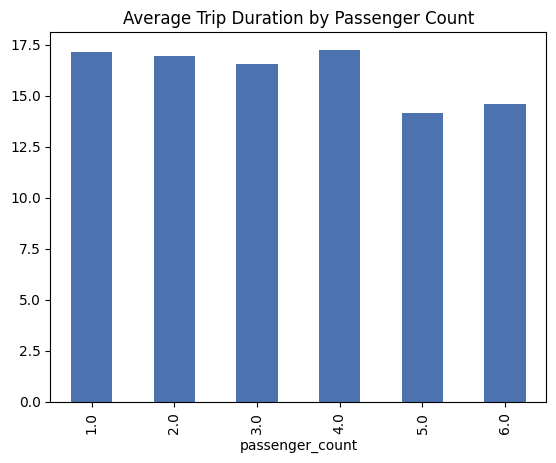

In [34]:
df.groupby("passenger_count")["trip_duration"].mean().plot(kind="bar")
plt.title("Average Trip Duration by Passenger Count")
plt.show()

## 👥 2. Average Trip Duration by Passenger Count

### 📌 Observation
- Trip duration remains **relatively stable across passenger counts**.
- Slight fluctuations exist but no strong trend is visible.
- 3–4 passenger trips show marginally higher duration.

### 🧠 Interpretation
- Passenger count has **minimal impact** on trip duration.
- Operational factors dominate over occupancy effects.

### ⚠️ Modeling Insight
- Passenger count is a **low-importance feature**, but still useful for minor variation capture.


# 10. Correlation Analysis

We check linear relationships between numerical features.

In [35]:
corr = df[[
    "trip_distance",
    "trip_duration",
    "pickup_hour",
    "pickup_dayofweek"
]].corr()

corr

,trip_distance,trip_duration,pickup_hour,pickup_dayofweek
trip_distance,1.000000,0.750048,-0.037229,-0.008757
trip_duration,0.750048,1.000000,-0.020274,-0.047184
pickup_hour,-0.037229,-0.020274,1.000000,-0.055436
pickup_dayofweek,-0.008757,-0.047184,-0.055436,1.000000


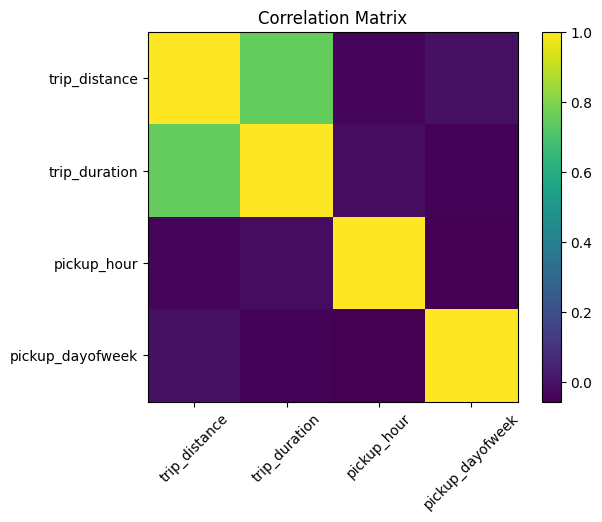

In [36]:
plt.imshow(corr)
plt.title("Correlation Matrix")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar()
plt.show()

## 📊 3. Correlation Matrix Analysis

### 📌 Observation
- Strong positive correlation:
  - trip_distance ↔ trip_duration
- Weak correlation:
  - pickup_hour ↔ trip_duration
  - pickup_dayofweek ↔ trip_duration
- No strong multicollinearity observed.

### 🧠Interpretation
- Distance is the primary driver of trip duration.
- Temporal features influence demand patterns more than duration directly.

### ⚠️ Modeling Insight
- Feature set is suitable for ML models.
- Non-linear models preferred for better interaction capture.


# 11. Time Series Analysis

We analyze how trip duration varies over time.

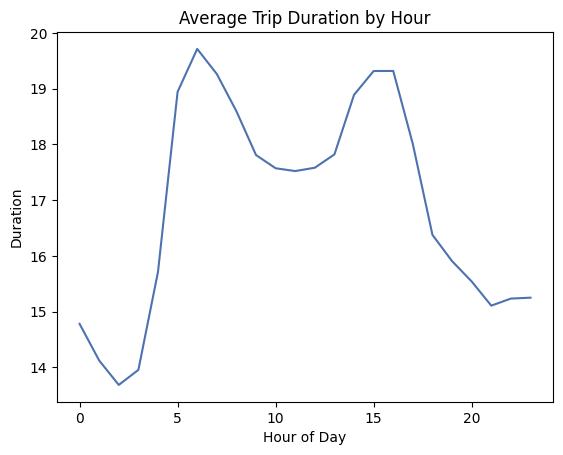

In [37]:
df.groupby("pickup_hour")["trip_duration"].mean().plot()
plt.title("Average Trip Duration by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Duration")
plt.show()

Peak hours often show higher trip duration due to congestion.

# 12. Geographic Analysis

We analyze location-based patterns using pickup and dropoff zones.

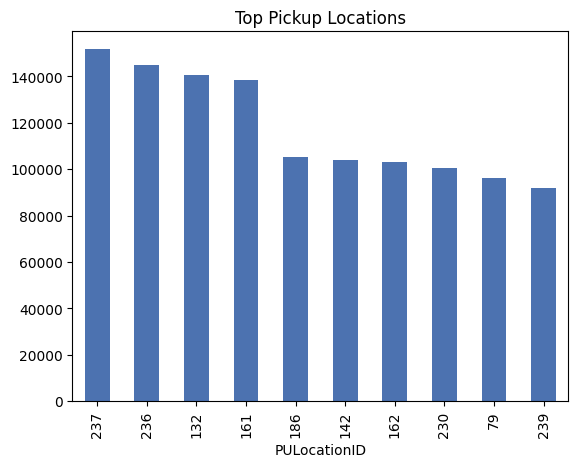

In [38]:
df["PULocationID"].value_counts().head(10).plot(kind="bar")
plt.title("Top Pickup Locations")
plt.show()

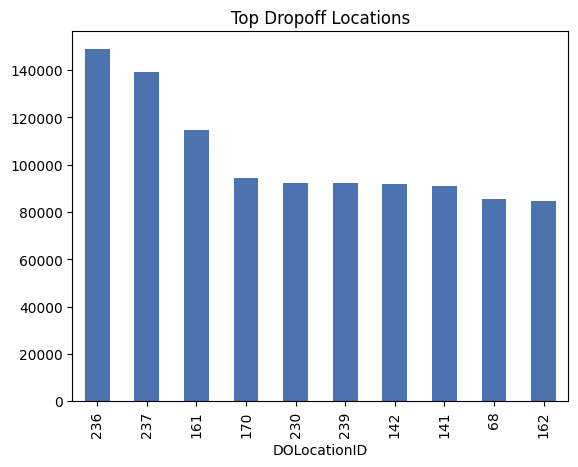

In [39]:
df["DOLocationID"].value_counts().head(10).plot(kind="bar")
plt.title("Top Dropoff Locations")
plt.show()

## 📍 5. Geographic Analysis (Pickup & Drop-off)

### 📌 Observation
- Certain pickup and drop-off zones dominate trip counts.
- Clear clustering of demand in specific locations.

### 🧠 Interpretation
- Taxi demand is **spatially uneven**.
- High-demand zones likely represent:
  - Airports ✈️
  - Business districts 🏢
  - Transit hubs 🚉

### ⚠️ Modeling Insight
- Location features are highly predictive.
- Encoding techniques (target/frequency encoding) are recommended.

---

# 13. Feature Engineering Review

We validate whether engineered features add predictive value.

In [40]:
df.groupby("is_rush_hour")["trip_duration"].mean()

is_rush_hour
0    16.704615
1    17.710527
Name: trip_duration, dtype: float64

In [41]:
df.groupby("is_weekend")["trip_duration"].mean()

is_weekend
0    17.772875
1    15.475125
Name: trip_duration, dtype: float64

Rush hour and weekend indicators help capture traffic-related variations in trip duration.

# 14. Statistical Tests

We test whether categorical features significantly affect trip duration.

In [44]:
rush_hour = df[df["is_rush_hour"] == 1]["trip_duration"]
non_rush_hour = df[df["is_rush_hour"] == 0]["trip_duration"]

print("Rush Hour:",rush_hour.mean())
print("Non-Rush Hour:",non_rush_hour.mean())

Rush Hour: 17.710526632094467
Non-Rush Hour: 16.70461499276706


A noticeable difference suggests that rush hour has statistical impact on trip duration.

# 15. Business Insights
1. Trip distance is the strongest predictor of trip duration.
2. Rush hours significantly increase travel time.
3. Certain pickup zones dominate demand.
4. Weekends show different travel behavior compared to weekdays.
5. Temporal features are critical for forecasting accuracy.
